In [3]:
# =====================================================================
# 步驟 1（全新一條龍版）：直接讀取原始資料並在本地完成清洗與分組
# =====================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. 直接讀取最源頭的 CSV 檔案
raw_data_path = "../data/raw/YRBS_2007.csv"
df_raw = pd.read_csv(raw_data_path)

# 2. 挑出這次雙因子分析需要的 4 個核心原始欄位
core_columns = ["WhatIsYourSex", "PhysicalFighting", "TelevisionWatching", "ComputerUse"]
df_selected = df_raw[core_columns].copy()

# 3. 剔除任何有缺失值 (NaN) 的學生資料
df_cleaned = df_selected.dropna().copy()

# 4. 還原螢幕時間為實際小時數
screen_time_map = {1: 0.0, 2: 0.5, 3: 1.0, 4: 2.0, 5: 3.0, 6: 4.0, 7: 5.0}
df_cleaned['TV_Hours'] = df_cleaned['TelevisionWatching'].map(screen_time_map)
df_cleaned['Game_Hours'] = df_cleaned['ComputerUse'].map(screen_time_map)
df_cleaned['Total_Screen_Time'] = df_cleaned['TV_Hours'] + df_cleaned['Game_Hours']

# 5. 重新對打架次數進行分組（並直接過濾掉 Unknown）
def recode_fighting(value):
    if value == 1:
        return "1_None"
    elif value in [2, 3, 4]:
        return "2_Occasional"
    elif value in [5, 6, 7]:
        return "3_Frequent"
    else:
        return "Unknown"

df_cleaned['Fighting_Group'] = df_cleaned['PhysicalFighting'].apply(recode_fighting)
df_final = df_cleaned[df_cleaned['Fighting_Group'] != "Unknown"].copy()

# 6. 將性別代號 (1.0, 2.0) 轉換為容易閱讀的文字
sex_map = {1.0: "Female", 2.0: "Male"}
df_final['Sex'] = df_final['WhatIsYourSex'].map(sex_map)

# 讓這個轉換好、最乾淨的 df_final 變成後續步驟使用的 df
df = df_final.dropna(subset=['Sex'])

# =====================================================================
# ✨ 新增：將雙因子專用資料表另存成全新的 CSV 檔
# =====================================================================
output_2way_path = "../data/processed/YRBS_2007_two_way_ready.csv"
df.to_csv(output_2way_path, index=False)
print(f"[成功] 雙因子專用資料表已另存新檔至：\n 👉 {output_2way_path}")

print(f"【重新讀取成功】")
print(f"有效學生樣本數：{df.shape[0]} 筆。")
print("資料欄位確認：", df[['Sex', 'Fighting_Group', 'Total_Screen_Time']].head())

# =====================================================================
# 步驟 2：執行雙因子變異數分析 (Two-way ANOVA)
# =====================================================================
model_2way = ols('Total_Screen_Time ~ C(Fighting_Group) * C(Sex)', data=df).fit()
anova_2way_table = sm.stats.anova_lm(model_2way, typ=2)

print("\n=== 雙因子變異數分析 (Two-way ANOVA) 統計結果 ===")
display(anova_2way_table)

[成功] 雙因子專用資料表已另存新檔至：
 👉 ../data/processed/YRBS_2007_two_way_ready.csv
【重新讀取成功】
有效學生樣本數：13144 筆。
資料欄位確認：       Sex Fighting_Group  Total_Screen_Time
2    Male   2_Occasional                3.0
3  Female         1_None                0.0
5  Female         1_None                0.0
6  Female         1_None                4.5
7  Female         1_None                2.5

=== 雙因子變異數分析 (Two-way ANOVA) 統計結果 ===


,sum_sq,df,F,PR(>F)
C(Fighting_Group),215.782230,2.0,17.963112,1.619446e-08
C(Sex),766.361370,1.0,127.593780,1.882849e-29
C(Fighting_Group):C(Sex),85.523884,2.0,7.119563,8.122459e-04
Residual,78910.238767,13138.0,NaN,NaN


## 04_雙因子變異數分析 (Two-way ANOVA) 與交互作用探討

本筆記本的目標有兩個：
1. **執行 Two-way ANOVA 檢定**：同時將「打架頻率」與「性別」放入模型，檢定這兩個自變數是否會共同影響青少年的每日總螢幕時間。
2. **檢定交互作用 (Interaction Effect)**：探討「打架頻率對螢幕時間的影響，是否會因為性別（男生或女生）而有所不同？」
3. **繪製交互作用折線圖 (Interaction Plot)**：視覺化男女生在不同打架組別中的螢幕時間趨勢變化。

### 📐 欄位與性別代號對照
根據 CDC 原始手冊，性別欄位 `WhatIsYourSex` 的代號如下：
* `1.0` $\rightarrow$ **Female (女生)**
* `2.0` $\rightarrow$ **Male (男生)**
* 其他或缺失值 $\rightarrow$ 在前置清洗時已自動過濾

In [4]:
# =====================================================================
# 步驟 1：讀取資料並將性別代號轉換為文字標籤
# =====================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 讀取我們在 02 步驟存好的分組資料
df = pd.read_csv("../data/processed/YRBS_2007_two_way_ready.csv")

# 原始資料的 WhatIsYourSex 是 1 和 2，我們把它換成看得懂的文字
sex_map = {1.0: "Female", 2.0: "Male"}
df['Sex'] = df['WhatIsYourSex'].map(sex_map)

# 再次確認沒有遺漏值
df = df.dropna(subset=['Sex', 'Fighting_Group', 'Total_Screen_Time'])

# =====================================================================
# 步驟 2：執行雙因子變異數分析 (Two-way ANOVA)
# =====================================================================
# 語法中的 * 代表同時計算：打架主效應、性別主效應、以及兩者的「交互作用效應」
model_2way = ols('Total_Screen_Time ~ C(Fighting_Group) * C(Sex)', data=df).fit()
anova_2way_table = sm.stats.anova_lm(model_2way, typ=2)

print("=== 雙因子變異數分析 (Two-way ANOVA) 統計結果 ===")
display(anova_2way_table)

=== 雙因子變異數分析 (Two-way ANOVA) 統計結果 ===


,sum_sq,df,F,PR(>F)
C(Fighting_Group),215.782230,2.0,17.963112,1.619446e-08
C(Sex),766.361370,1.0,127.593780,1.882849e-29
C(Fighting_Group):C(Sex),85.523884,2.0,7.119563,8.122459e-04
Residual,78910.238767,13138.0,NaN,NaN


In [5]:
# =====================================================================
# 步驟 3：計算男女生在各打架組別中的詳細平均時數
# =====================================================================
print("--- 男女生在各打架頻率群體中的每日總螢幕時間矩陣 ---")
interaction_summary = df.groupby(['Sex', 'Fighting_Group'])['Total_Screen_Time'].mean().unstack().round(2)
display(interaction_summary)

--- 男女生在各打架頻率群體中的每日總螢幕時間矩陣 ---


Fighting_Group,1_None,2_Occasional,3_Frequent
Sex,,,
Female,3.39,3.73,4.30
Male,3.99,4.00,4.51


[成功] 交互作用折線圖已成功存檔至：
 👉 ../outputs/figures\screen_time_interaction_plot.png


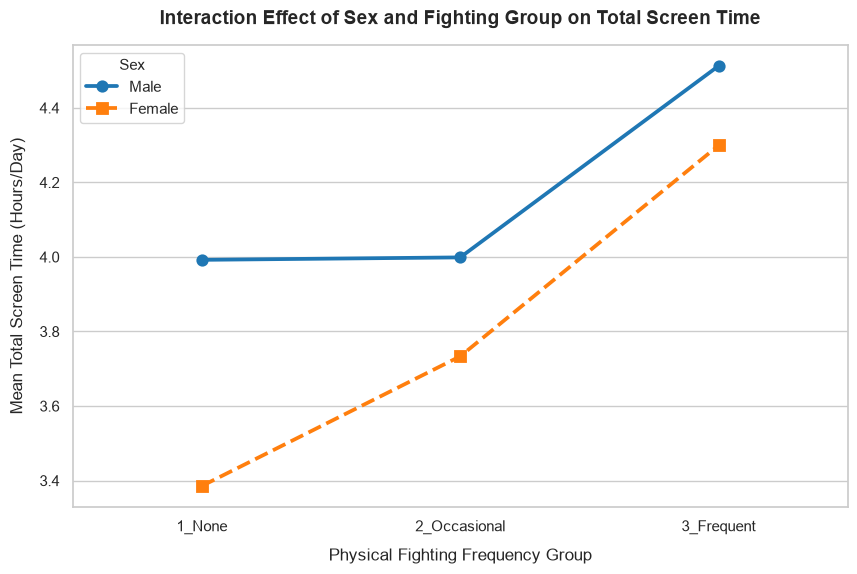

In [6]:
# =====================================================================
# 步驟 4：繪製交互作用折線圖 (Interaction Plot) 並另存新檔
# =====================================================================
fig_dir = "../outputs/figures"
group_order = ['1_None', '2_Occasional', '3_Frequent']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 使用 pointplot 畫出兩條折線，一條代表男生，一條代表女生
sns.pointplot(
    data=df, 
    x='Fighting_Group', 
    y='Total_Screen_Time', 
    hue='Sex', 
    order=group_order,
    palette={'Female': '#ff7f0e', 'Male': '#1f77b4'}, # 女生用橘線，男生用藍線
    markers=["o", "s"], # 圓形與方形標記
    linestyles=["-", "--"], # 實線與虛線
    errorbar=None # 不顯示複雜的誤差條，讓圖表最乾淨
)

# 設定圖表標題與標籤
plt.title('Interaction Effect of Sex and Fighting Group on Total Screen Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Physical Fighting Frequency Group', fontsize=12, labelpad=10)
plt.ylabel('Mean Total Screen Time (Hours/Day)', fontsize=12, labelpad=10)
plt.legend(title='Sex', title_fontsize='11', loc='upper left')

# 儲存這張高含金量的延伸圖表
interaction_output_path = os.path.join(fig_dir, "screen_time_interaction_plot.png")
plt.savefig(interaction_output_path, dpi=300, bbox_inches='tight')
print(f"[成功] 交互作用折線圖已成功存檔至：\n 👉 {interaction_output_path}")

plt.show()